# Practical Assignment I: Multilayer Perceptrons

Multilayer perceptron (MLP) is a fully connected, feedforward neural network architecture. It consists of one input layer, one or more hidden layers, and one output layer. Each layer consists of units (also called neurons, or nodes).

Each unit is connected to every unit in a neighboring layer, hence fully connected. This is why in Keras these layers are called `Dense`. Information flows from left to right, hence feedforward.

<img src="https://edirlei.com/images/nn1.png" width="800">

**Learning objectives:**

At the end of this DataLab, you will be able to build MLPs using Keras for the following problem types:

 - Regression
 - Binary classification
 - Multi-class classification
 - Multi-label classification
 
For each type, you will be given a suitable dataset. Then you will:

 - Pre-process the data if needed
 - Create a `Sequential()` model
 - Compile the model by defining a loss function, an optimizer and the metrics to be calculated
 - Train the model using the `fit()` method
 - Test the model using the `predict()` and `evaluate()` methods
 
 
 **Notebook contents:**
 
 1. Regression
 2. Binary classification
 3. Multi-class classification
 4. Multi-label classification

**Packages:**

Let's start by importing the basic packages required for this DataLab:

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

## 1. Regression

The goal of a regression task is to predict a continuous outcome variable (dependent variable) based on one or more predictor variables (independent variables).

**The dataset**

In this task, you will use the diabetes dataset provided by `scikit-learn`.

Please read the dataset documentation before you start:

https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset

Now let's load the data and display some samples from the dataset:

In [7]:
from sklearn import datasets
diabetes = datasets.load_diabetes()
X = diabetes.data
y = diabetes.target
names = ['age','sex','bmi','bp','tc','ldl','hdl','tch','ltg','glu']
Xy_combined = np.concatenate((X, y[:, np.newaxis]), axis=1)
df = pd.DataFrame(Xy_combined,
                  columns=names + ['disease progression'])
df.head()

,age,sex,bmi,bp,tc,ldl,hdl,tch,ltg,glu,disease progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Let's split the dataset into a training set and a testing set using function ``train_test_split``:

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.33,
                                                    random_state=0)

Now we can visualize the dimensions of the sets:

In [9]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((296, 10), (146, 10), (296,), (146,))

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


**Task 1.1**
Build an MLP suitable for the diabetes dataset. Use a `Sequential()` model and `Dense` layers from Keras. You are free to pick any number of hidden layers and any number of units per layer as long as it works.  Use suitable activation functions.

In [11]:
# YOUR CODE HERE #
model = Sequential([
            Dense(64,activation='relu',input_shape=(X_train.shape[1],)),
            Dense(32,activation='relu'),
            Dense(16,activation='relu'),
            Dropout(0.2),
            Dense(1)
])



**Task 1.2**
Using `model.compile()`, compile the model. Select a suitable optimizer and a suitable loss function. Also include a metric or metrics.

In [12]:
# YOUR CODE HERE #

model.compile(optimizer='adam',loss='mse',metrics=['mae'])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                704       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dropout (Dropout)           (None, 16)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 3329 (13.00 KB)
Trainable params: 3329 (13.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**Task 1.3** Using `model.fit()` Train the model on X_train, y_train and use X_test, y_test as validation data. Pick a suitable number of epochs and batch size.

In [13]:
# YOUR CODE HERE #
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test), verbose=1)


Epoch 1/100


19/19 [==============================] - 1s 8ms/step - loss: 29130.9023 - mae: 151.2407 - val_loss: 28832.1191 - val_mae: 153.4943
Epoch 2/100
19/19 [==============================] - 0s 2ms/step - loss: 28888.9180 - mae: 150.3948 - val_loss: 28559.0312 - val_mae: 152.5565
Epoch 3/100
19/19 [==============================] - 0s 2ms/step - loss: 28478.9590 - mae: 148.9094 - val_loss: 27933.9297 - val_mae: 150.4541
Epoch 4/100
19/19 [==============================] - 0s 2ms/step - loss: 27515.3203 - mae: 145.5890 - val_loss: 26556.3887 - val_mae: 145.8218
Epoch 5/100
19/19 [==============================] - 0s 2ms/step - loss: 25550.2930 - mae: 138.4527 - val_loss: 23711.4355 - val_mae: 135.9284
Epoch 6/100
19/19 [==============================] - 0s 2ms/step - loss: 21434.5840 - mae: 123.4113 - val_loss: 18655.2754 - val_mae: 116.3859
Epoch 7/100
19/19 [==============================] - 0s 2ms/step - loss: 15864.1602 - mae: 102.0875 - val_loss: 11965.6055 - val_mae: 88.407

**Task 1.4** Evaluate the model using `model.evaluate()`.

In [14]:
# YOUR CODE HERE #
test_loss,test_mae=model.evaluate(X_test,y_test)
print(f'test MAE : {test_mae:.4f}')

5/5 [==============================] - 0s 2ms/step - loss: 3415.0833 - mae: 45.9296
test MAE : 45.9296


**Task 1.5** Get predictions on `X_test` using the `model.predict()` function. Then, we will plot `y_test` vs. predictions. On the same plot, we will show a $x = y$ line. Think about what this line represents.

5/5 [==============================] - 0s 1ms/step


Text(0, 0.5, 'Predictions')

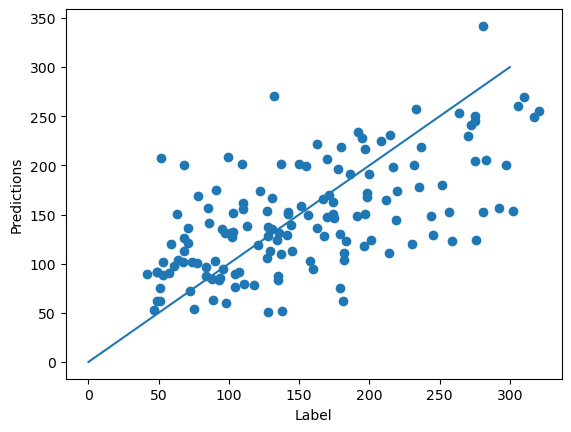

In [15]:
preds = model.predict(X_test) # REPLACE None BY YOUR CODE

plt.scatter(y_test, preds)
plt.plot([0, 300], [0, 300])
plt.xlabel('Label')
plt.ylabel('Predictions')

If you implemented everything correctly, the output will be similar to the following plot:

<img src="https://edirlei.com/images/mlp-w1-output1.png" width="500">

## 2. Binary Classification

Binary classification is a type of classification where a model is trained to categorize data points into one of two categories. 

**The dataset**

In this task, you will use the breast cancer dataset provided by `scikit-learn`.

Please read the dataset documentation before you start:

https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset

Now let's load the data and display some samples from the dataset:

In [16]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
names = list(cancer.feature_names)
Xy_combined = np.concatenate((X, y[:, np.newaxis]), axis=1)
df = pd.DataFrame(Xy_combined,
                  columns=names + ['Benign'])
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Benign
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0.0


Let's split the dataset into a training set and a testing set using function ``train_test_split``:

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.33,
                                                    random_state=0)

Now we can visualize the dimensions of the sets:

In [18]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((381, 30), (188, 30), (381,), (188,))

In [19]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


**Task 2.1**
Build an MLP suitable for the breast cancer dataset. Use a `Sequential()` model and `Dense` layers from Keras. You are free to pick any number of hidden layers and any number of units per layer as long as it works. Use suitable activation functions.

In [20]:
# YOUR CODE HERE #
model=Sequential([
            Dense(128,activation='relu',input_shape=(X_train.shape[1],)),
            Dense(64,activation='relu'),
            Dense(32,activation='relu'),
            Dense(16,activation='relu'),
            Dropout(0.2),
            Dense(1)

])




**Task 2.2**
Compile the model by selecting a suitable optimizer and a suitable loss function. Also include a metric or metrics.

In [21]:
# YOUR CODE HERE #

model.compile(optimizer='adam',loss='mae',metrics=['mae'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 128)               3968      
                                                                 
 dense_5 (Dense)             (None, 64)                8256      
                                                                 
 dense_6 (Dense)             (None, 32)                2080      
                                                                 
 dense_7 (Dense)             (None, 16)                528       
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                                 
 dense_8 (Dense)             (None, 1)                 17        
                                                                 
Total params: 14849 (58.00 KB)
Trainable params: 14849

**Task 2.3**
Train the model on X_train, y_train and use X_test, y_test as validation data. Pick a suitable number of epochs and batch size.

In [22]:
# YOUR CODE HERE #
history= model.fit(X_train,y_train,epochs=100,batch_size=16,validation_data=(X_test,y_test))

Epoch 1/100
24/24 [==============================] - 1s 6ms/step - loss: 0.3492 - mae: 0.3492 - val_loss: 0.2379 - val_mae: 0.2379
Epoch 2/100
24/24 [==============================] - 0s 2ms/step - loss: 0.2126 - mae: 0.2126 - val_loss: 0.2106 - val_mae: 0.2106
Epoch 3/100
24/24 [==============================] - 0s 2ms/step - loss: 0.1865 - mae: 0.1865 - val_loss: 0.1793 - val_mae: 0.1793
Epoch 4/100
24/24 [==============================] - 0s 2ms/step - loss: 0.1680 - mae: 0.1680 - val_loss: 0.1631 - val_mae: 0.1631
Epoch 5/100
24/24 [==============================] - 0s 2ms/step - loss: 0.1455 - mae: 0.1455 - val_loss: 0.1745 - val_mae: 0.1745
Epoch 6/100
24/24 [==============================] - 0s 2ms/step - loss: 0.1545 - mae: 0.1545 - val_loss: 0.1375 - val_mae: 0.1375
Epoch 7/100
24/24 [==============================] - 0s 2ms/step - loss: 0.1470 - mae: 0.1470 - val_loss: 0.1374 - val_mae: 0.1374
Epoch 8/100
24/24 [==============================] - 0s 2ms/step - loss: 0.1352 - m

**Task 2.4**
Evaluate the model using `model.evaluate()`.

In [23]:
# YOUR CODE HERE #

test_loss,test_mae=model.evaluate(X_test,y_test)
print(f'Test MAE: {test_mae:.4f}')

6/6 [==============================] - 0s 1ms/step - loss: 0.0561 - mae: 0.0561
Test MAE: 0.0561


**Task 2.5**
Get predictions on `X_test` using the `model.predict()` function. Then, we will plot the confusion matrix for your trained model on the test set.

6/6 [==============================] - 0s 1ms/step


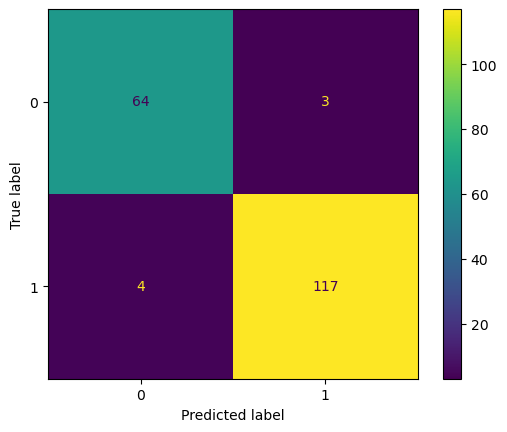

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

preds = model.predict(X_test) # REPLACE None BY YOUR CODE

preds_binary = (preds>0.5)*1 # converts the output into binary
cm = confusion_matrix(y_test, preds_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot()

If you implemented everything correctly, the confusion matrix will be similar to the following:

<img src="https://edirlei.com/images/mlp-w1-output2.png" width="500">

## 3. Multi-class Classification

Multi-class classification is a task where an instance or sample can be classified into more than two categories or classes.

**The dataset**

In this task, you will use the MNIST dataset provided by `keras`.

Please read the dataset documentation before you start:

https://keras.io/api/datasets/mnist/

Now let's load the dataset (notice that function ``mnist.load_data`` automatizally splits the data into a training set and a testing set):

In [25]:
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

To visualize how the samples look like, we can display a random sample from the dataset:

Label: 4


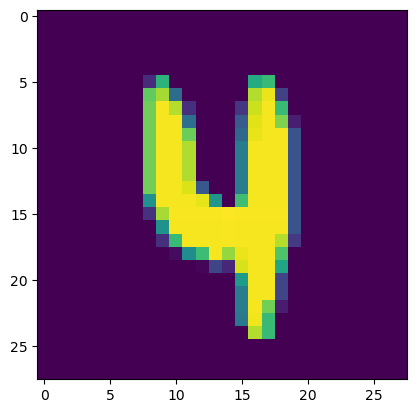

In [26]:
# View random digit
index = np.random.randint(0, 60000)
plt.imshow(X_train[index])
print('Label:', y_train[index])

We can also visualize the dimensions of the sets:

In [27]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

**Task 3.1**
The MLP architecture you will build is given below. 784 input units, two hidden layers with 30 units each, one output layer with 10 units. 

<img src="https://edirlei.com/images/nn2.png" width="500">

**Important**: Notice that X_train/X_test shape and the input layer shape of the network are not compatible (X_train shape is ``(, 28, 28)``, but the expected input layer shape is ``(, 784)``). Similarly, y_train/y_test and the output layer shape of the network, are not compatible (y_train shape is ``(,1)``, but the expected output layer shape is ``(,10)``). To solve this problem, you need to preprocess the data to make them compatible. Here are some hints on how to solve this problem:

- You can solve the incompatibility of the input by using the [reshape function](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html).
- You can solve the incompatibility of the output by using one-hot encoding through the [to_categorical function](https://www.tensorflow.org/api_docs/python/tf/keras/utils/to_categorical).



In [28]:
# YOUR CODE HERE #
X_train = X_train.reshape(-1, 784).astype("float32") / 255.0
X_test = X_test.reshape(-1, 784).astype("float32") / 255.0


In [29]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


**Task 3.2**
Build an MLP suitable for the MNIST dataset. Use a `Sequential()` model and `Dense` layers from Keras. Build the architecture shown in Task 3.1 Use suitable activation functions.

In [30]:
# YOUR CODE HERE #
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model=Sequential([
        Dense(30,activation='relu',input_shape=(784,)),
        Dense(30,activation='relu'),
        Dense(10,activation='softmax')
])

**Task 3.3**
Compile the model by selecting a suitable optimizer and a suitable loss function. Also include a metric or metrics.

In [31]:
# YOUR CODE HERE #
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics='accuracy')
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 30)                23550     
                                                                 
 dense_10 (Dense)            (None, 30)                930       
                                                                 
 dense_11 (Dense)            (None, 10)                310       
                                                                 
Total params: 24790 (96.84 KB)
Trainable params: 24790 (96.84 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**Task 3.4**
Train the model on X_train, y_train and use X_test, y_test as validation data. Pick a suitable number of epochs and batch size.

In [32]:
# YOUR CODE HERE #
history=model.fit(X_train,y_train,epochs=20,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/20
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3367 - accuracy: 0.9019 - val_loss: 0.1871 - val_accuracy: 0.9434
Epoch 2/20
1875/1875 [==============================] - 2s 921us/step - loss: 0.1714 - accuracy: 0.9498 - val_loss: 0.1540 - val_accuracy: 0.9525
Epoch 3/20
1875/1875 [==============================] - 2s 876us/step - loss: 0.1370 - accuracy: 0.9589 - val_loss: 0.1305 - val_accuracy: 0.9611
Epoch 4/20
1875/1875 [==============================] - 2s 897us/step - loss: 0.1150 - accuracy: 0.9658 - val_loss: 0.1427 - val_accuracy: 0.9574
Epoch 5/20
1875/1875 [==============================] - 2s 885us/step - loss: 0.1008 - accuracy: 0.9699 - val_loss: 0.1203 - val_accuracy: 0.9646
Epoch 6/20
1875/1875 [==============================] - 2s 900us/step - loss: 0.0903 - accuracy: 0.9723 - val_loss: 0.1153 - val_accuracy: 0.9667
Epoch 7/20
1875/1875 [==============================] - 2s 878us/step - loss: 0.0801 - accuracy: 0.9754 - val_loss: 0.1163 - v

**Task 3.5**
Evaluate the model using `model.evaluate()`.

In [33]:
# YOUR CODE HERE #
test_lose,test_acc=model.evaluate(X_test,y_test)
print(f'Test accuracy: {test_acc:.4f}')

313/313 [==============================] - 0s 646us/step - loss: 0.1391 - accuracy: 0.9665
Test accuracy: 0.9665


**Task 3.6**
Get predictions on `X_test` using the `model.predict()` function. Then, we will plot the confusion matrix for your trained model on the test set.

313/313 [==============================] - 0s 575us/step


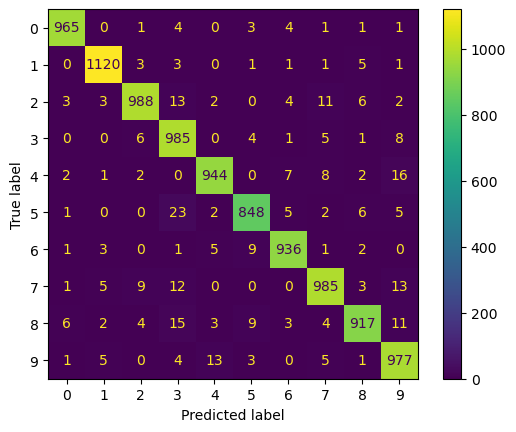

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

preds = model.predict(X_test)

y_test_indices = np.argmax(y_test, axis=1)
y_pred_indices = np.argmax(preds, axis=1)

cm = confusion_matrix(y_test_indices, y_pred_indices)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

If you implemented everything correctly, the confusion matrix will be similar to the following:

<img src="https://edirlei.com/images/mlp-w1-output3.png" width="500">

## 4. Multi-label Classification

Multi-label classification is a type of classification where an instance (or data point) can be classified into multiple classes or categories simultaneously. This is different from multi-class classification, where each instance is assigned to only one class.

**The dataset**

In this task you will use a simulated dataset.

You are given 4 random integers ($x_1, x_2, x_3, x_4$) between -5 and 5 ($x_i \in [-5, 5]$). Your task is to develop an MLP that predicts parity and sign of the product of these four numbers ($x_1 \times x_2 \times x_3 \times x_4$).

**Definitions**

In mathematics, parity is the property of an integer of whether it is even or odd.

In mathematics, the sign of a real number is its property of being either positive, negative, or zero.

**Example**

$x_1=-1, x_2=1, x_3=-3, x_4=-5$

$ product = x_1 \times x_2 \times x_3 \times x_4 = -15$

parity of -15 is `odd` and sign of -15 is `negative`.

**Columns**

$x_i$: Integers between -5 (inclusive) and 5 (inclusive).

Parity column: $x_1 \times x_2 \times x_3 \times x_4$ is even (0) or odd (1).

Sign column: $x_1 \times x_2 \times x_3 \times x_4$ is negative (-1), or zero (0) or positive (1).

|$x_1$|$x_2$|$x_3$|$x_4$|$Parity$|$Sign$|
|:--|:--|:--|:--|:--|:--|
|-2|-4|-1|1|0|-1|
|-3|5|-3|3|1|1|
|-4|-2|5|3|0|1|
|-4|0|-5|0|0|0|
|1|1|2|-4|0|-1|
|-1|1|-3|-5|1|-1|


Based on these definitions, we can write a function to generate a simulated dataset:

In [35]:
def simulator(n):
    
    # x_i numbers with shape (n, 4)
    X = np.random.randint(-5, 6, size=(n, 4))

    # product of 4 numbers for each row
    # this will be used to calculate labels
    # but this won't be part of the dataset
    product = np.prod(X, axis=1)

    # label 1
    parity_col = product % 2
    parity_col = parity_col.reshape(-1, 1)

    # label 2
    pos = (product > 0)*1
    neg = (product < 0)*-1
    zero = (product == 0)*0
    sign_col = pos + neg + zero
    sign_col = sign_col.reshape(-1, 1)

    # concatenate columns to create the dataset
    dataset = np.concatenate((X, parity_col, sign_col), axis=1)
    
    return dataset

Now we can create the dataset:

In [36]:
dataset = simulator(n=10000)

To see how the data look like, we can display some samples from the dataset:

In [37]:
df = pd.DataFrame(dataset, columns=['x_1', 'x_2', 'x_3', 'x_4', 'Parity', 'Sign'])
df.head(10)

,x_1,x_2,x_3,x_4,Parity,Sign
0,-5,2,5,4,0,-1
1,2,-3,5,-2,0,1
2,4,0,4,5,0,0
3,-5,-2,2,-1,0,-1
4,-3,0,4,1,0,0
5,2,4,4,2,0,1
6,1,-3,-4,4,0,1
7,3,3,-3,-5,1,1
8,1,4,-2,-5,0,1
9,-4,1,-1,3,0,1


Now let's use the numpy array `dataset` to create `X` and `y`:

In [38]:
X = dataset[:, 0:4]

parity_col = dataset[:, 4:5]

pos_col = np.zeros_like(dataset[:, -1])
pos_col[dataset[:, -1] == 1] = 1
pos_col = pos_col.reshape(-1, 1)

neg_col = np.zeros_like(dataset[:, -1])
neg_col[dataset[:, -1] == -1] = 1
neg_col = neg_col.reshape(-1, 1)

y = np.concatenate((parity_col, pos_col, neg_col), axis=1)

X.shape, y.shape

((10000, 4), (10000, 3))

After preprocessing the data, we can split the dataset into a training set and a testing set using function ``train_test_split``:

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.33,
                                                    random_state=0)

Then we can visualize the dimensions of the sets:

In [40]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((6700, 4), (6700, 3), (3300, 4), (3300, 3))

**Task 4.1**
Build a MLP suitable for this simulated dataset. Use a `Sequential()` model and `Dense` layers from Keras. Use suitable activation functions.

In [41]:
# YOUR CODE HERE #
model = Sequential()
model.add(Dense(30, input_shape=(4,), activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(30, activation='relu'))
model.add(Dense(3, activation='sigmoid'))
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 30)                150       
                                                                 
 dense_13 (Dense)            (None, 30)                930       
                                                                 
 dense_14 (Dense)            (None, 30)                930       
                                                                 
 dense_15 (Dense)            (None, 3)                 93        
                                                                 
Total params: 2103 (8.21 KB)
Trainable params: 2103 (8.21 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**Task 4.2**
Compile the model by selecting a suitable optimizer and a suitable loss function. Also include a metric or metrics.

In [44]:
# YOUR CODE HERE #
model.compile(optimizer='adam', 
              loss='binary_crossentropy',
              metrics='accuracy')

**Task 4.3**
Train the model on X_train, y_train and use X_test, y_test as validation data. Pick a suitable number of epochs and batch size.

In [45]:
# YOUR CODE HERE #
history = model.fit(X_train, y_train,
                    epochs=20, batch_size=32,
                    validation_data=(X_test, y_test))


Epoch 1/20
210/210 [==============================] - 1s 2ms/step - loss: 0.5464 - accuracy: 0.4148 - val_loss: 0.4827 - val_accuracy: 0.5121
Epoch 2/20
210/210 [==============================] - 0s 1ms/step - loss: 0.4021 - accuracy: 0.5585 - val_loss: 0.3341 - val_accuracy: 0.5682
Epoch 3/20
210/210 [==============================] - 0s 1ms/step - loss: 0.2759 - accuracy: 0.5887 - val_loss: 0.2467 - val_accuracy: 0.5888
Epoch 4/20
210/210 [==============================] - 0s 1ms/step - loss: 0.2117 - accuracy: 0.5982 - val_loss: 0.1987 - val_accuracy: 0.5985
Epoch 5/20
210/210 [==============================] - 0s 1ms/step - loss: 0.1776 - accuracy: 0.6191 - val_loss: 0.1756 - val_accuracy: 0.6197
Epoch 6/20
210/210 [==============================] - 0s 1ms/step - loss: 0.1593 - accuracy: 0.6693 - val_loss: 0.1664 - val_accuracy: 0.6345
Epoch 7/20
210/210 [==============================] - 0s 1ms/step - loss: 0.1483 - accuracy: 0.7067 - val_loss: 0.1529 - val_accuracy: 0.7445
Epoch 

**Task 4.4**
Evaluate the model using `model.evaluate()`.

In [46]:
# YOUR CODE HERE #
model.evaluate(X_test, y_test)

104/104 [==============================] - 0s 743us/step - loss: 0.1200 - accuracy: 0.8770


[0.119968943297863, 0.8769696950912476]

**Task 4.5**
Get predictions on `X_test` using the `model.predict()` function. Then, we will calculate the exact match radio for your trained model on the test set.

In [47]:
from sklearn.metrics import accuracy_score

preds =model.predict(X_test) # REPLACE None BY YOUR CODE
preds_binary = (preds>0.5)*1

exact_match = accuracy_score(y_test, preds_binary)
print("Exact Match Ratio:", exact_match)

104/104 [==============================] - 0s 626us/step
Exact Match Ratio: 0.9027272727272727


If you implemented everything correctly, the exact match ratio should be around 0.9 (90%).